# Stage 2 — Feedforward Neural Network
### Imports

In [1]:
import torch 
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, precision_score, recall_score,
    f1_score, roc_curve, auc
)

### Set Device (GPU/CPU)


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")                   

Using device: cuda


### Load and Prepare Data


In [3]:
df = pd.read_csv('../data/IMDB Dataset.csv')
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative':0})

X = df['review']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train).toarray()
X_test_tfidf  = tfidf.transform(X_test).toarray()

print(f"Training samples: {X_train_tfidf.shape}")
print(f"Testing samples:  {X_test_tfidf.shape}")


Training samples: (40000, 5000)
Testing samples:  (10000, 5000)


### Convert to PyTorch Tensors


In [4]:
X_train_tensor = torch.FloatTensor(X_train_tfidf).to(device)
X_test_tensor  = torch.FloatTensor(X_test_tfidf).to(device)
y_train_tensor = torch.FloatTensor(y_train.values.copy()).to(device)
y_test_tensor  = torch.FloatTensor(y_test.values.copy()).to(device)

print(f"X_train_tensor shape: {X_train_tensor.shape}")
print(f"Device: {X_train_tensor.device}")

X_train_tensor shape: torch.Size([40000, 5000])
Device: cuda:0


## Build the Neural Network


In [5]:
class SentimentNN(nn.Module):
    def __init__(self):
        super(SentimentNN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(5000, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.network(x).squeeze()

model = SentimentNN().to(device)
print(model)

SentimentNN(
  (network): Sequential(
    (0): Linear(in_features=5000, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=256, out_features=1, bias=True)
    (7): Sigmoid()
  )
)


---
## DataLoaders
Wrapping tensors in `TensorDataset` + `DataLoader` enables automatic mini-batching and shuffling during training.

In [6]:
BATCH_SIZE = 64

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset  = TensorDataset(X_test_tensor,  y_test_tensor)

# shuffle=True on training prevents ordering artifacts;
# shuffle=False on test keeps evaluation deterministic.
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Test  batches: {len(test_loader)}")

Train batches: 625
Test  batches: 157


---
## Loss, Optimiser & Scheduler
- **BCELoss** — correct choice for a single sigmoid output (binary cross-entropy).  
- **AdamW** — like Adam but applies weight decay correctly; `lr=1e-3`, `weight_decay=1e-4` adds mild L2 regularisation.  
- **ReduceLROnPlateau** — halves the learning rate when val-loss stalls for 3 consecutive epochs, helping the model escape flat regions.

In [7]:
criterion = nn.BCELoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',       # watch for loss going down
    factor=0.5,       # multiply LR by 0.5 on plateau
    patience=3,       # wait 3 epochs before reducing
    verbose=True
)

c:\Users\manos\Desktop\PROJECTS\sentiment-analyzer\venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


---
## Early Stopping
Stops training when validation loss has not improved by more than `min_delta` for `patience` consecutive epochs, and restores the best weights seen so far.

In [8]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=1e-4):
        self.patience   = patience
        self.min_delta  = min_delta
        self.counter    = 0
        self.best_loss  = float('inf')
        self.best_state = None

    def step(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss  = val_loss
            self.counter    = 0
            # Clone weights so later epochs can't overwrite this snapshot
            self.best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            self.counter += 1
        return self.counter >= self.patience  # True → stop

    def restore(self, model):
        """Load the best-checkpoint weights back into the model."""
        if self.best_state:
            model.load_state_dict(self.best_state)
            print(f"Restored best weights (val_loss={self.best_loss:.4f})")

early_stopping = EarlyStopping(patience=5)

---
## Training & Evaluation Functions
`train_epoch` runs one full pass over the training set.  
`eval_epoch` runs one full pass over any loader and returns a metrics dict — used for both validation and final test evaluation.

In [9]:
def train_epoch(model, loader, criterion, optimizer):
    """One training epoch. Returns (avg_loss, accuracy)."""
    model.train()   # activates Dropout
    total_loss, correct, total = 0.0, 0, 0

    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()                   # clear stale gradients
        preds = model(X_batch)                  # forward pass
        loss  = criterion(preds, y_batch)        # compute loss
        loss.backward()                         # backpropagation

        # Clamp gradient norm to 1.0 — prevents exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()                        # update weights

        total_loss += loss.item() * len(y_batch)
        correct    += ((preds >= 0.5) == y_batch).sum().item()
        total      += len(y_batch)

    return total_loss / total, correct / total


def eval_epoch(model, loader, criterion):
    """Evaluate model on loader. Returns (metrics_dict, y_pred, y_true, y_proba)."""
    model.eval()    # disables Dropout
    total_loss  = 0.0
    all_preds   = []
    all_labels  = []
    all_probs   = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            probs = model(X_batch)
            total_loss += criterion(probs, y_batch).item() * len(y_batch)
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend((probs >= 0.5).cpu().numpy().astype(int))
            all_labels.extend(y_batch.cpu().numpy().astype(int))

    n = len(all_labels)
    metrics = {
        'loss':      total_loss / n,
        'accuracy':  accuracy_score(all_labels, all_preds),
        'precision': precision_score(all_labels, all_preds),
        'recall':    recall_score(all_labels, all_preds),
        'f1':        f1_score(all_labels, all_preds),
    }
    return metrics, all_preds, all_labels, all_probs

---
## Training Loop
Trains for up to 30 epochs with early stopping. Each epoch prints a one-line summary; the scheduler adjusts the LR automatically when val-loss plateaus.

In [10]:
EPOCHS = 30

history = {
    'train_loss': [], 'val_loss': [],
    'train_acc':  [], 'val_acc':  [],
    'val_f1':     []
}

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc         = train_epoch(model, train_loader, criterion, optimizer)
    val_metrics, _, _, _          = eval_epoch(model, test_loader, criterion)

    scheduler.step(val_metrics['loss'])

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_metrics['loss'])
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_metrics['accuracy'])
    history['val_f1'].append(val_metrics['f1'])

    print(
        f"Epoch {epoch:02d}/{EPOCHS}  "
        f"train_loss={train_loss:.4f}  "
        f"val_loss={val_metrics['loss']:.4f}  "
        f"val_acc={val_metrics['accuracy']:.4f}  "
        f"f1={val_metrics['f1']:.4f}"
    )

    if early_stopping.step(val_metrics['loss'], model):
        print(f"\nEarly stopping triggered at epoch {epoch}.")
        break

early_stopping.restore(model)

Epoch 01/30  train_loss=0.3112  val_loss=0.2544  val_acc=0.8934  f1=0.8941
Epoch 02/30  train_loss=0.2224  val_loss=0.2609  val_acc=0.8922  f1=0.8936
Epoch 03/30  train_loss=0.1720  val_loss=0.2849  val_acc=0.8917  f1=0.8925
Epoch 04/30  train_loss=0.0931  val_loss=0.3702  val_acc=0.8839  f1=0.8833
Epoch 05/30  train_loss=0.0323  val_loss=0.4879  val_acc=0.8825  f1=0.8820
Epoch 06/30  train_loss=0.0097  val_loss=0.7037  val_acc=0.8822  f1=0.8861

Early stopping triggered at epoch 6.
Restored best weights (val_loss=0.2544)


---
## Training Curves
A gap between train and val curves indicates overfitting. A flattening val curve before train loss flattens is a sign of the scheduler/early-stopping doing its job.

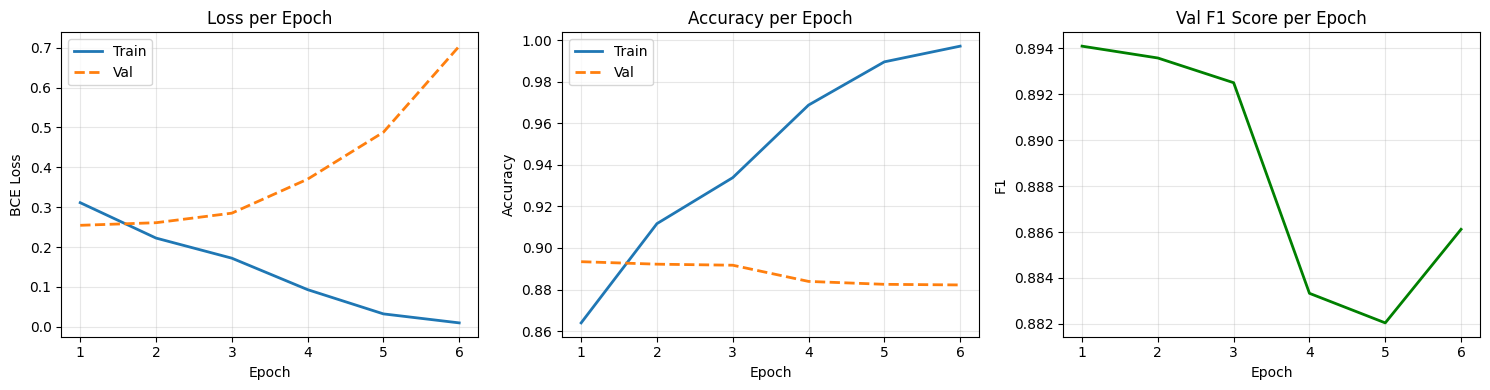

In [11]:
epochs_ran = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss
axes[0].plot(epochs_ran, history['train_loss'], label='Train', linewidth=2)
axes[0].plot(epochs_ran, history['val_loss'],   label='Val',   linewidth=2, linestyle='--')
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(epochs_ran, history['train_acc'], label='Train', linewidth=2)
axes[1].plot(epochs_ran, history['val_acc'],   label='Val',   linewidth=2, linestyle='--')
axes[1].set_title('Accuracy per Epoch')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

# F1
axes[2].plot(epochs_ran, history['val_f1'], color='green', linewidth=2)
axes[2].set_title('Val F1 Score per Epoch')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('F1')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

---
## Final Test Evaluation

In [12]:
final_metrics, y_pred, y_true, y_probs = eval_epoch(model, test_loader, criterion)

print("── Final Test Metrics ─────────────────────────────")
for k, v in final_metrics.items():
    print(f"  {k:<12}: {v:.4f}")

print("\n── Classification Report ──────────────────────────")
print(classification_report(y_true, y_pred, target_names=['Negative', 'Positive']))

── Final Test Metrics ─────────────────────────────
  loss        : 0.2544
  accuracy    : 0.8934
  precision   : 0.8952
  recall      : 0.8930
  f1          : 0.8941

── Classification Report ──────────────────────────
              precision    recall  f1-score   support

    Negative       0.89      0.89      0.89      4961
    Positive       0.90      0.89      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



---
## Confusion Matrix

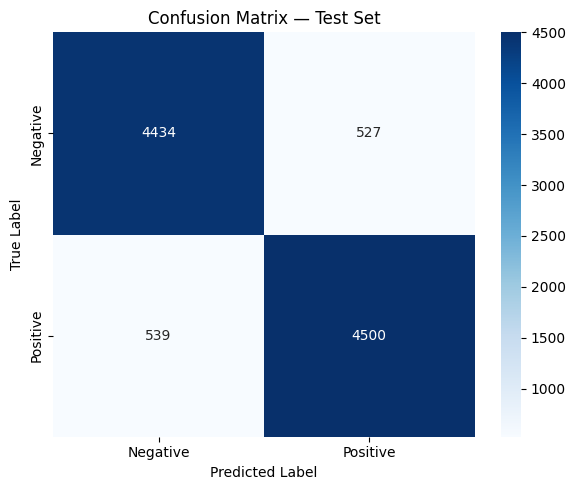

TN=4434  FP=527  FN=539  TP=4500


In [13]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive'],
    ax=ax
)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")

---
## ROC Curve & AUC
AUC measures how well the model separates the two classes across all possible thresholds. A value of 1.0 is perfect; 0.5 is random chance.

Optimal decision threshold: 0.483
AUC: 0.9607


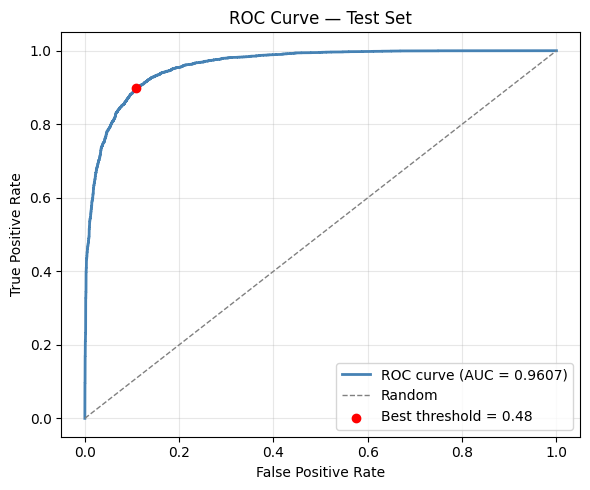

In [14]:
fpr, tpr, thresholds = roc_curve(y_true, y_probs)
roc_auc = auc(fpr, tpr)

# Find the threshold that maximises (TPR - FPR) — Youden's J statistic
best_idx   = np.argmax(tpr - fpr)
best_thresh = thresholds[best_idx]
print(f"Optimal decision threshold: {best_thresh:.3f}")
print(f"AUC: {roc_auc:.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='steelblue', linewidth=2,
        label=f'ROC curve (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Random')
ax.scatter(fpr[best_idx], tpr[best_idx], color='red', zorder=5,
           label=f'Best threshold = {best_thresh:.2f}')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Test Set')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

---
## Inference on Custom Text
A helper function to run a raw review string through the trained model.

In [15]:
def predict_sentiment(review_text: str, threshold: float = 0.5) -> dict:
    """
    Predict sentiment for a single raw review string.
    Returns a dict with 'label', 'confidence', and 'probability'.
    """
    model.eval()
    # Reuse the fitted TF-IDF vectoriser from training
    vec   = tfidf.transform([review_text]).toarray()
    tensor = torch.FloatTensor(vec).to(device)

    with torch.no_grad():
        prob = model(tensor).item()

    label = 'Positive' if prob >= threshold else 'Negative'
    conf  = prob if prob >= threshold else 1 - prob
    return {'label': label, 'probability': round(prob, 4), 'confidence': round(conf, 4)}


# --- Examples ---
samples = [
    "This movie was absolutely fantastic! The acting was superb.",
    "Terrible film. Waste of two hours. The plot made no sense at all.",
    "It was okay, nothing special but not bad either."
]

for text in samples:
    result = predict_sentiment(text)
    print(f"[{result['label']}] (p={result['probability']}, conf={result['confidence']})")
    print(f"  → {text[:70]}...\n")

[Positive] (p=0.9914, conf=0.9914)
  → This movie was absolutely fantastic! The acting was superb....

[Negative] (p=0.0003, conf=0.9997)
  → Terrible film. Waste of two hours. The plot made no sense at all....

[Negative] (p=0.0057, conf=0.9943)
  → It was okay, nothing special but not bad either....



---
## Save Model
Saves only the model weights (`state_dict`), which is the standard PyTorch convention — lighter and more portable than pickling the whole model object.

In [16]:
torch.save(model.state_dict(), 'sentiment_model.pt')
print("Model saved → sentiment_model.pt")

# To reload later:
# loaded_model = SentimentNN().to(device)
# loaded_model.load_state_dict(torch.load('sentiment_model.pt'))
# loaded_model.eval()

Model saved → sentiment_model.pt
